# Chessboard tile detection using OpenCV Contour Detection

In [55]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import os

Read sample image from file and convert to gray scale because for detecting the chessboard tiles we only care about the difference between dark and bright.

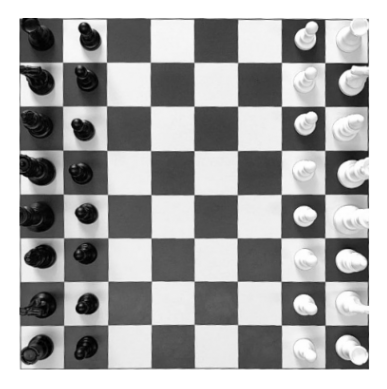

In [56]:
image = cv2.imread('../samples/chessboard.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

Use a blur filter to remove some of the contrast and edge details on the chess pieces so that is will not detect too much unnecessary edges in the image.

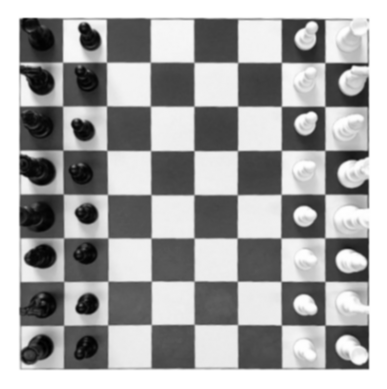

In [57]:
blurred = cv2.GaussianBlur(gray, (3, 3), 0)
plt.imshow(blurred, cmap='gray')
plt.axis('off')
plt.show()

Threshold the image to get a binary image so that edges of the pieces will mostly be removed

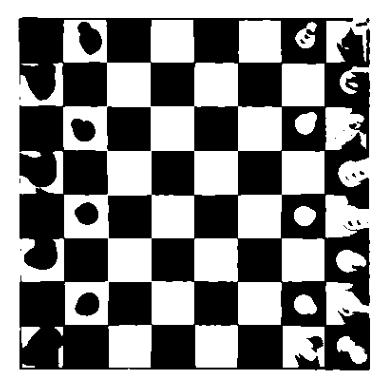

In [58]:
threshold_kernel_size = blurred.shape[0] // 4 * 2 + 1
thresholed = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, threshold_kernel_size, 3
)

plt.imshow(thresholed, cmap='gray')
plt.axis('off')
plt.show()

Apply canny edge detection algoritm to extract the contours in the image

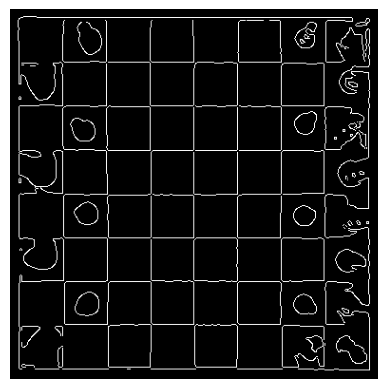

In [59]:
edges = cv2.Canny(thresholed, 50, 200, apertureSize=3)

# kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
# edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

Use the houghline algoritm to extract lines with given threshold out of the image and draw the lines with minimal length of 1000 so that it will exeed the lenght of the image

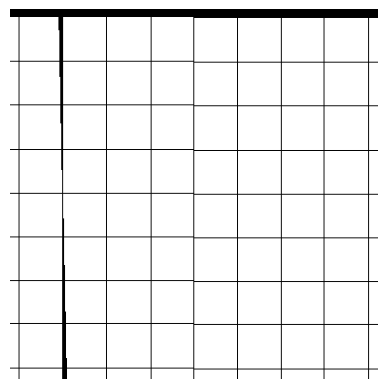

In [60]:
# Detect hough lines in the warped image to draw grid
lines = cv2.HoughLines(edges, 1, np.pi / 180, 125)

# Create black image to draw lines on grayscale 1 channel
line_image = np.ones_like(gray) * 255

# Draw the detected lines on the warped image
if lines is not None:
    for rho, theta in lines[:, 0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(line_image, (x1, y1), (x2, y2), (0, 0, 0), 2)

# Draw border around the line image to avoid false positives at the edges
border_size = 1
line_image[:border_size, :] = 0
line_image[-border_size:, :] = 0
line_image[:, :border_size] = 0
line_image[:, -border_size:] = 0

cv2.erode(line_image, np.ones((3, 3), np.uint8), iterations=3, dst=line_image)
cv2.dilate(line_image, np.ones((3, 3), np.uint8), iterations=4, dst=line_image)


plt.imshow(line_image, cmap='gray')
plt.axis('off')
plt.show()

Use countour detection of opencv to extract the chessboard tile contours from the image after that filter only square like contours

In [61]:
# Line image is a binary image with grid lines
# Extract all the grid squares from the line image
contours, _ = cv2.findContours(line_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) 
rectangles = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = w / h
    if 0.8 < aspect_ratio < 1.2 and w > 20 and h > 20:  # Filter for square-like contours
        
        # Add small margin to the bounding box to avoid cutting off the edges of the cells
        margin = 2  # Adjust this value as needed
        x = max(x - margin, 0)
        y = max(y - margin, 0)
        w = min(w + 2 * margin, line_image.shape[1] - x)
        h = min(h + 2 * margin, line_image.shape[0] - y)
        rectangles.append((x, y, w, h))


# Sort the rectangles from left to right, top to bottom
rectangles.sort(key=lambda r: (r[1] // 50, r[0] // 50))

print(f'Found {len(rectangles)} rectangles')

# Extract all rectangles from the warped image to two dimensional list of cells
cells = [[] for _ in range(8)]
for (x, y, w, h) in rectangles:
    # Determine the row and column of the cell based on its center position
    col = int((x + w / 2) // w)
    row = int((y + h / 2) // h)
    print(f'Row: {row}, Col: {col}, x: {x}, y: {y}, w: {w}, h: {h}')
    cell = image[y:y+h, x:x+w]
    cells[row].append(cell)  

Found 64 rectangles
Row: 0, Col: 0, x: 8, y: 6, w: 46, h: 50
Row: 0, Col: 1, x: 54, y: 6, w: 49, h: 50
Row: 0, Col: 3, x: 147, y: 6, w: 48, h: 50
Row: 0, Col: 2, x: 100, y: 6, w: 50, h: 50
Row: 0, Col: 4, x: 192, y: 7, w: 49, h: 50
Row: 0, Col: 5, x: 238, y: 7, w: 49, h: 50
Row: 0, Col: 6, x: 284, y: 7, w: 48, h: 50
Row: 0, Col: 7, x: 329, y: 7, w: 50, h: 50
Row: 2, Col: 0, x: 8, y: 99, w: 48, h: 50
Row: 1, Col: 0, x: 8, y: 53, w: 47, h: 49
Row: 2, Col: 1, x: 54, y: 99, w: 49, h: 50
Row: 1, Col: 1, x: 54, y: 53, w: 49, h: 49
Row: 2, Col: 3, x: 147, y: 99, w: 48, h: 50
Row: 2, Col: 2, x: 100, y: 99, w: 50, h: 50
Row: 1, Col: 3, x: 147, y: 53, w: 48, h: 49
Row: 1, Col: 2, x: 100, y: 53, w: 50, h: 49
Row: 1, Col: 4, x: 192, y: 54, w: 49, h: 49
Row: 1, Col: 5, x: 238, y: 54, w: 49, h: 49
Row: 1, Col: 6, x: 284, y: 54, w: 48, h: 49
Row: 1, Col: 7, x: 329, y: 54, w: 50, h: 49
Row: 3, Col: 0, x: 8, y: 146, w: 49, h: 49
Row: 3, Col: 1, x: 54, y: 146, w: 49, h: 49
Row: 3, Col: 3, x: 147, y: 146

First topleft squeare should have the black rook

Extracted 64 cells


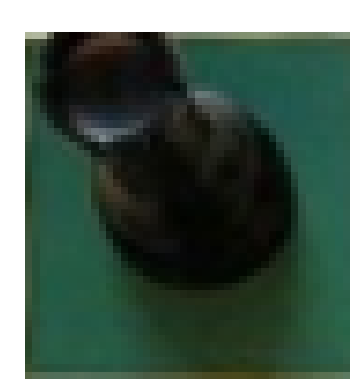

In [62]:
print(f'Extracted {sum(len(row) for row in cells)} cells')
plt.imshow(cells[0][0])
plt.axis('off')
plt.show()

Write the squares to disk so it can be used for chesspiece detection

In [63]:
# Remove the old images in the out directory
out_dir = 'out'
if os.path.exists(out_dir):
    for file in os.listdir(out_dir):
        os.remove(os.path.join(out_dir, file))
else:
    os.makedirs(out_dir)

print(cells[0][0].shape)

# Write each cell to a separate image file in chess notation order (a1, a2, ..., h8)
for row in range(8):
    for col in range(8):
        cell = cells[row][col]
        # Chess notation: a1 is bottom-left, h8 is top-right
        chess_notation = f"{chr(ord('a') + col)}{8 - row}"
        out_path = os.path.join(out_dir, f"{chess_notation}.png")
        cv2.imwrite(out_path, cv2.cvtColor(cell, cv2.COLOR_RGB2BGR))

(50, 46, 3)
